In [1]:
import pandas as pd
import seaborn as sns
import pingouin as pg 

/opt/conda/lib/python3.9/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.3, the latest is 0.6.1.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


In [2]:
data = pd.read_csv('csv_data/diabetes.csv')

Вопрос:

Отличается ли уровень глюкозы (Glucose) между пациентами с диабетом и без?

In [3]:
data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [4]:
data = data[['Glucose', 'Outcome']]

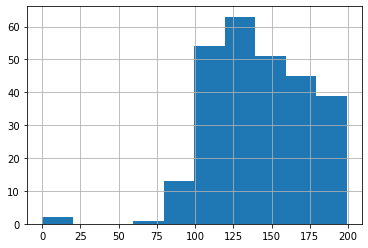

In [5]:
data[data.Outcome == 1].Glucose.hist()
print()

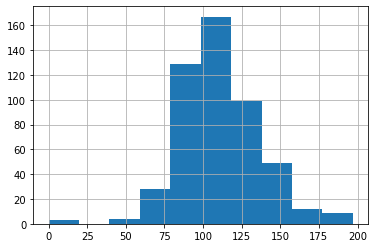

In [6]:
data[data.Outcome == 0].Glucose.hist()

In [7]:
pg.normality(data, dv='Glucose', group='Outcome')

,W,pval,normal
Outcome,,,
1,0.958820,6.587326e-07,False
0,0.967946,5.447241e-09,False


In [8]:
pg.homoscedasticity(data, dv='Glucose', group='Outcome')

,W,pval,equal_var
levene,20.945339,0.000006,False


При ненормальности распределений и отсутствии гомогенности дисперсий следует использовать непараметрический аналаг Т-теста - критерий Манна-Уитни.


In [9]:
pg.mwu(x = data[data.Outcome == 0].Glucose, y = data[data.Outcome == 1].Glucose)

,U-val,alternative,p-val,RBC,CLES
MWU,28390.5,two-sided,1.200727e-39,0.576261,0.211869


Уровень глюкозы статистически значимо различается между пациентами с диабетом и без (p < 0.01). Непараметрический анализ показал, что значения глюкозы у пациентов с диабетом существенно выше. Размер эффекта является большим (RBC ≈ 0.58), что указывает на значимое и практически важное различие между группами.